<div align="center">

#####

#Teoría de Circuitos 2

##Trabajo Práctico N°1

**Estudiante:** Nahir Lewartowski

</div>

---

##Función transferencia, parámetros $ω$, $Q$ y $k$

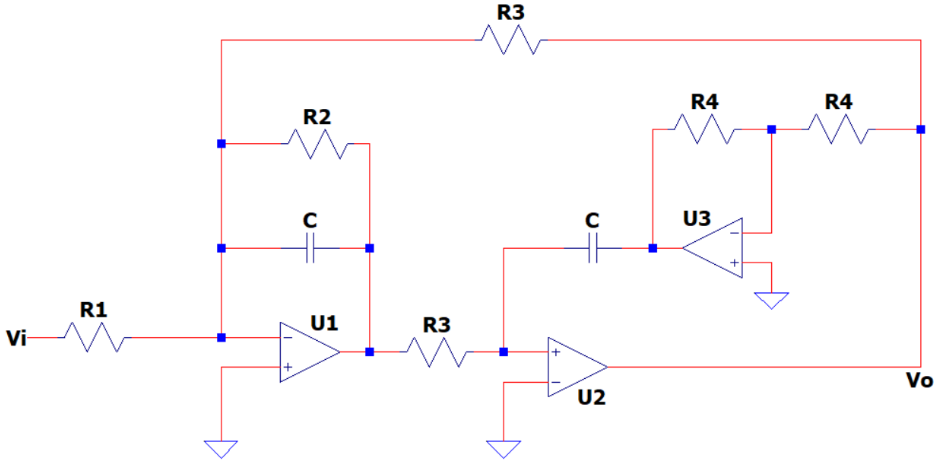

Redibujo el circuito para simplificar la visualización y nombrar nodos

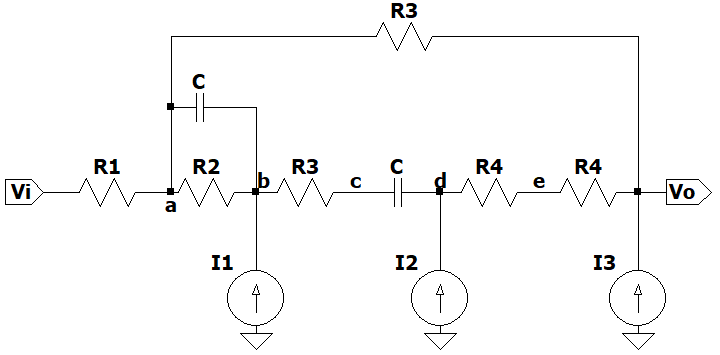

$$V_a=V_c=V_e=0$$

$$V_d=-V_o$$

KCL en nodo C:

$$\displaystyle \frac{V_b-V_c}{R_3}=(V_c-V_d)\cdot sC$$

$$\displaystyle V_b=- V_d \,sC  R_3$$

$$\displaystyle V_b= V_o \,sC  R_3$$

KCL en nodo A:

$$\displaystyle \frac{V_i-V_a}{R_1}=\frac{V_a-V_b}{1/sC}+\frac{V_a-V_b}{R_2}+\frac{V_a-V_o}{R_3}$$

$$\displaystyle \frac{V_i}{R_1}=-V_b \cdot sC-\frac{V_b}{R_2}-\frac{V_o}{R_3}$$

Reemplazo con la expresión obtenida del nodo A:

$$\displaystyle \frac{V_i}{R_1}=-(V_o \,sC  R_3) \cdot sC-\frac{V_o \,sC  R_3}{R_2}-\frac{V_o}{R_3}$$

$$\displaystyle \frac{V_i}{R_1}= -V_o ( s^2 C^2  R_3 + \frac{ sC  R_3}{R_2}+\frac{1}{R_3})$$

$$\displaystyle \frac{V_o}{V_i}= - \frac{1}{R_1} \frac{1}{s^2 C^2  R_3 + s \frac{ C  R_3}{R_2}+\frac{1}{R_3}}$$

$$\displaystyle \frac{V_o}{V_i}= - \frac{1}{C^2 R_1 R_3} \cdot \frac{1}{s^2 + s \frac{1}{C R_2}+\frac{1}{C^2 R_3^2}}$$

Forma canónica de pasabajos: $$\displaystyle H(s)=k \frac{\omega_o^2}{s^2 + \frac{\omega_o}{Q}s + \omega_o^2}$$

Frecuencia de corte: $\displaystyle \omega_o = \frac{1}{C R_3}$

Factor de calidad: $\displaystyle Q = \frac{R_2}{R_3}$

Ganancia en banda de paso: $\displaystyle k = -\frac{R_3}{R_1}$



##Pasabanda

Este circuito tiene la particularidad de que dependiendo de donde se tome la salida, puede ser un filtro pasabajos, pasabanda, etc.

Si tomamos $V_b$ como salida, llegaremos a un filtro pasabanda.

Del desarrollo anterior, sabemos que $V_b=V_o \,sC  R_3$

Dividimos ambos lados por $V_i$:

$\displaystyle \frac{V_b}{V_i}= \frac{V_o}{V_i} \,sC  R_3$

Reemplazo $\frac{V_o}{V_i}$ por la función obtenida anteriormente:

$\displaystyle \frac{V_b}{V_i}= - \frac{1}{C^2 R_1 R_3} \cdot \frac{1}{s^2 + s \frac{1}{C R_2}+\frac{1}{C^2 R_3^2}} \,sC  R_3$

$\displaystyle \frac{V_b}{V_i}= - \frac{1}{C R_1} \cdot \frac{s}{s^2 + s \frac{1}{C R_2}+\frac{1}{C^2 R_3^2}}$

Siendo $\displaystyle H(s) = k \frac{\frac{\omega_o}{Q}s}{s^2 + \frac{\omega_o}{Q}s + \omega_o^2}$ la forma canónica de un filtro pasabanda.

Frecuencia de corte, igual que el pasabajos: $\displaystyle \omega_o = \frac{1}{C R_3}$

Factor de calidad, igual que el pasabajos: $\displaystyle Q = \frac{R_2}{R_3}$

Ganancia en banda de paso: $\displaystyle k = -\frac{R_2}{R_1}$




#Normalización de pasabajos

Normas:

$$\omega_o = 1 \,rad/s$$

$$C = 1 \,F$$

$$|k|=1$$

$$R_4=1\,Ω$$

Por ende, los demás componentes resultan así:

$$\omega_o = \frac{1}{C \cdot R_3} ⇒ R_3=1 \,Ω$$

$$Q = \frac{R_2}{R_3} ⇒ R_2 = Q \,Ω$$

$$\displaystyle |k| = \frac{R_3}{R_1} ⇒ R_1 = 1 \,Ω$$



#Simulación en Python

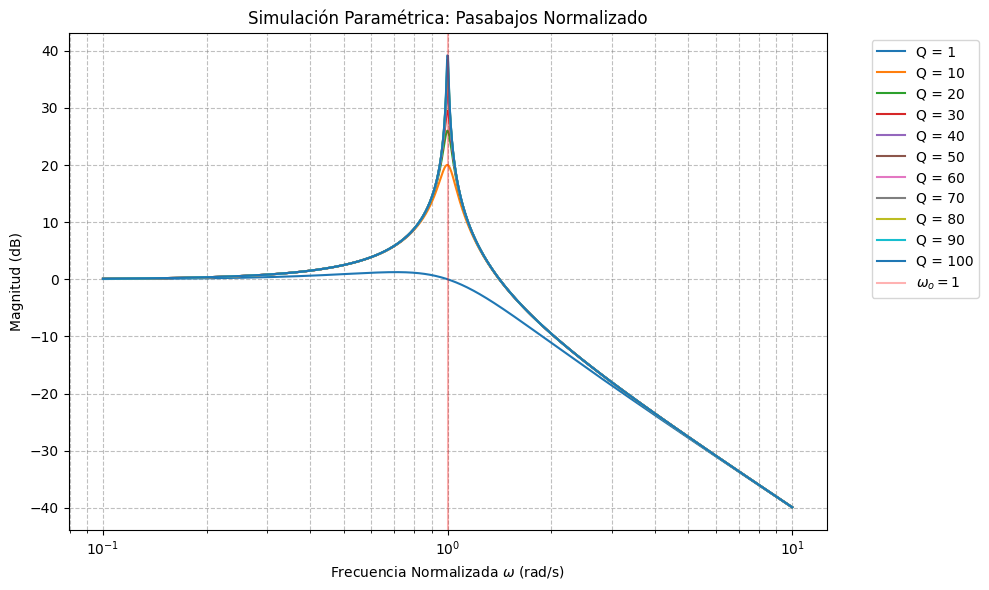

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

w = np.logspace(-1, 1, 1000)

plt.figure(figsize=(10, 6))

valores_Q = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for Q in valores_Q:

    num = [-1]

    den = [1, 1/Q, 1]

    sistema = signal.TransferFunction(num, den)
    w_out, magnitud, fase = signal.bode(sistema, w)

    plt.semilogx(w_out, magnitud, label=f'Q = {Q}')

plt.title('Simulación Paramétrica: Pasabajos Normalizado')
plt.xlabel(r'Frecuencia Normalizada $\omega$ (rad/s)')
plt.ylabel('Magnitud (dB)')

plt.grid(True, which="both", ls="--", color='gray', alpha=0.5)
plt.axvline(x=1, color='red', linestyle='-', alpha=0.3, label=r'$\omega_o = 1$')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Simulación en LTspice


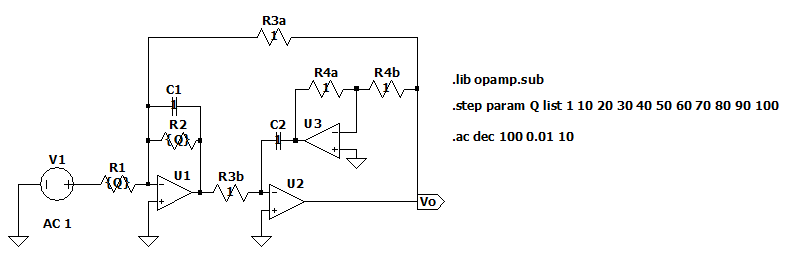

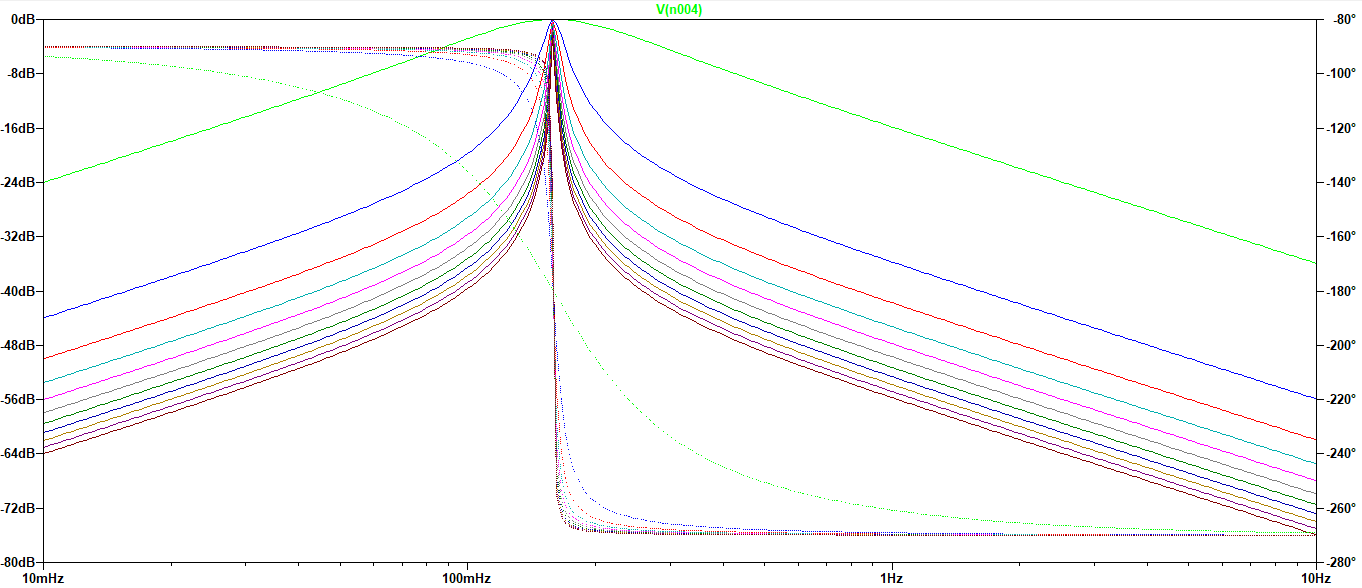

# Filtro pasabajos Chebyshev

Calculo $\epsilon$ usando la atenuación máxima en la banda de paso ($\alpha_{max} = 0.4 \text{ dB}$):

$$\alpha_{max} = 10 \log (1+ \epsilon^2)$$

$$0.4 = 10 \log (1+ \epsilon^2)$$

$$ \epsilon^2 = 10^{0.04} - 1 \approx 0.096478$$

Fórmula general de atenuación para la banda de detención:

$$\alpha_{min} = 10 \log \left( 1 + \epsilon^2 \cosh^2(n \cosh^{-1}(\Omega_s)) \right)$$

Sabiendo que la frecuencia normalizada es $\Omega_s = \frac{f_s}{f_p} = \frac{9600 \text{ Hz}}{3200 \text{ Hz}} = 3$, iteramos el orden $n$:

Para $n = 3$:
$$\alpha = 10 \log \left( 1 + 0.096478 \cdot \cosh^2(3 \cdot \cosh^{-1}(3)) \right) \approx 29.7 \text{ dB}$$

Para $n = 4$:
$$\alpha = 10 \log \left( 1 + 0.096478 \cdot \cosh^2(4 \cdot \cosh^{-1}(3)) \right) \approx 45.0 \text{ dB}$$

Para $n = 5$:
$$\alpha = 10 \log \left( 1 + 0.096478 \cdot \cosh^2(5 \cdot \cosh^{-1}(3)) \right) \approx 60.3 \text{ dB}$$

Al superar los $48 \text{ dB}$ exigidos por la plantilla, el orden del filtro debe ser $n=5$.

###Factor de deformación:

$$a = \frac{1}{n} \sinh^{-1}\left(\frac{1}{\epsilon}\right) \approx 0.3771$$

$$\sinh(a) \approx 0.3862$$

$$\cosh(a) \approx 1.0719$$

###Ubicación de los polos:

$$\theta_k = \frac{(2k-1)\pi}{2n}$$

Con $n=5$

$$\theta_k = \frac{(2k-1)\pi}{10}$$

$k = 1$: $s_1 = -0.1193 + j1.0195$

$k = 2$: $s_2 = -0.3124 + j0.6301$

$k = 3$: $s_3 = -0.3862$

$k = 4$: $s_4 = -0.3124 - j0.6301$

$k = 5$: $s_5 = -0.1193 - j1.0195$

Agrupo los polos conjugados $s_2$ y $s_4$, $s_1$ y $s_5$.

$$(s - p_k)(s - p_k^*) = s^2 + 2|\sigma|s + (\sigma^2 + \omega^2)$$

$$\omega_o = \sqrt{\sigma^2 + \omega^2}$$

$$Q = \frac{\omega_o}{2|\sigma|}$$

###Etapa formada por los polos $s_1$ y $s_5$:

$$\omega_{o1} \approx 1.0264 \text{ rad/s}$$

$$Q_1 \approx \mathbf{4.30}$$

###Etapa formada por los polos $s_2$ y $s_4$:

$$\omega_{o2} \approx 0.7033 \text{ rad/s}$$

$$Q_2 \approx 1.126$$

###Etapa Pasiva RC

$$\omega_{o3} = 0.3862 \text{ rad/s}$$

###Frecuencia angular real

$$\omega_p = 2 \pi \cdot f_p = 2 \pi \cdot 3200 \text{ Hz} \approx 20106.19 \text{ rad/s}$$

Etapa 1 ($s_1, s_5$):$$\omega_{real\_1} \approx 20637 \text{ rad/s}$$

Etapa 2 ($s_2, s_4$):$$\omega_{real\_2} \approx 14140 \text{ rad/s}$$

Etapa 3 (RC pasiva):$$\omega_{real\_3} \approx 7765 \text{ rad/s}$$

##Componentes reales

Fijo los capacitores en $C = 10$nF y $R_4 = 10 k\Omega$

$$\omega_o = \frac{1}{R_3 C} \implies R_3 = \frac{1}{\omega_o C}$$

$$Q = \frac{R_2}{R_3} \implies R_2 = Q \cdot R_3$$

$$\displaystyle |k| = \frac{R_3}{R_1} \implies R_3=R_1$$

###Etapa 1 (Polos 1 y 5)

Con $\omega_{real\_1} = 20637 \text{ rad/s}$, $Q_1 = 4.30$ y $C = 10 \text{ nF}$:

$$R_{3\_1} = \frac{1}{20637 \cdot 10 \times 10^{-9}} \approx 4.85 \text{ k}\Omega$$

$$R_{2\_1} = 4.30 \cdot 4846 \approx 20.8 \text{ k}\Omega$$

$$R_{1\_1} = R_{3\_1} \approx 4.85 \text{ k}\Omega$$

###Etapa 2 (Polos 2 y 4)

Con $\omega_{real\_2} = 14140 \text{ rad/s}$, $Q_2 = 1.126$ y $C = 10 \text{ nF}$:

$$R_{3\_2} = \frac{1}{14140 \cdot 10 \times 10^{-9}} \approx 7.07 \text{ k}\Omega$$

$$R_{2\_2} = 1.126 \cdot 7072 \approx 7.96 \text{ k}\Omega$$

$$R_{1\_2} = R_{3\_2} \approx 7.07 \text{ k}\Omega$$

###Etapa 3 (RC Pasiva - Polo 3)

Con frecuencia de corte $\omega_{real\_3} = 7765 \text{ rad/s}$.

$$R_{RC} = \frac{1}{\omega_{real\_3} \cdot C} = \frac{1}{7765 \cdot 10 \times 10^{-9}} \approx 12.88 \text{ k}\Omega$$


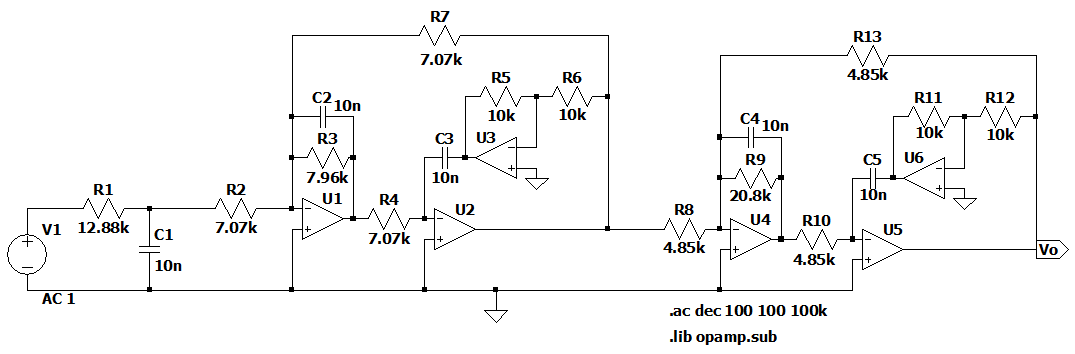

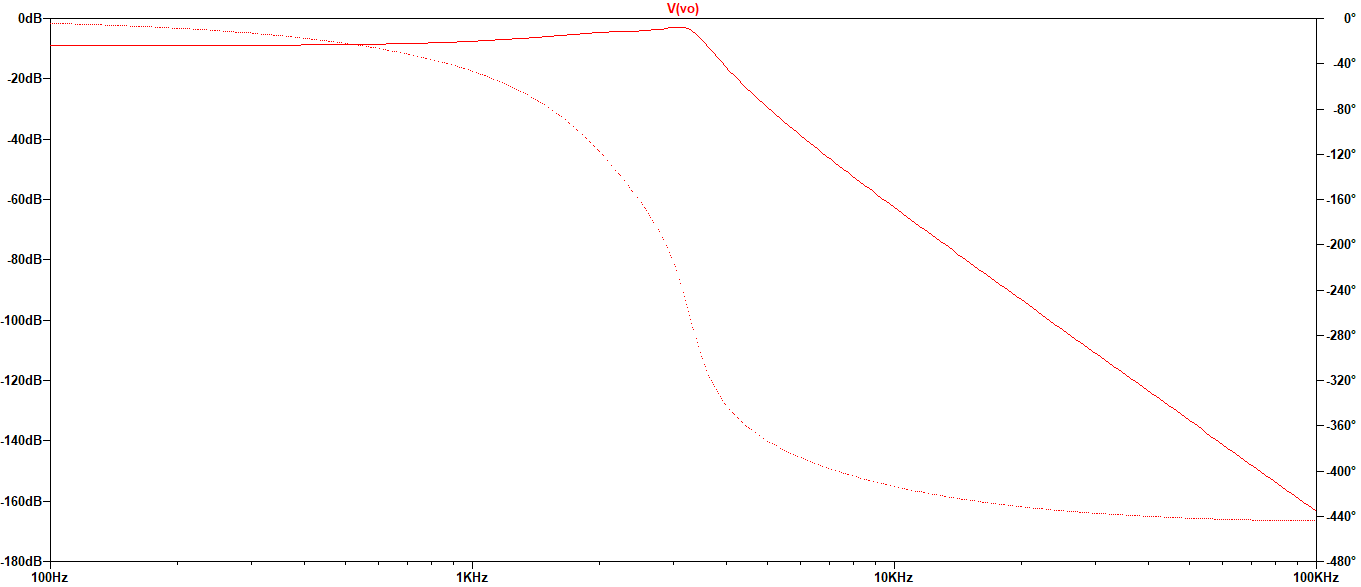